# Image-based Malware Classification using CNN




# Preprocessing - Converting to images

Raw malwares will be stored in the following folder:

In [1]:
root = r"C:\Users\aimaa\Desktop\Degree\Sem 6\FYP\Dataset\Ransomeware - Copy (2)\Train"

The following function allows us to convert our hexadecimal **.bytes** files stored into our 'data' folder, into PNG images.

# Preprocessing - Generate the dataset

In [2]:
root = r"C:\Users\aimaa\Desktop\Degree\FYP\Dataset\Wannacry\Train"


In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define augmentation parameters
batches = ImageDataGenerator().flow_from_directory(directory=root, target_size=(224,224), batch_size=303)




Found 303 images belonging to 2 classes.


In [4]:
batches.class_indices

{'Benign': 0, 'Ransomware': 1}

**batches** generated with ImageDataGenerator() is an iterator. Hence, we use next() to go through all its elements and generate a batch of images and labels from the data set.

In [5]:
imgs, labels = next(batches)

As you can see, our images are in RGB with shape 64x64 [width x length x depth].

In [6]:
imgs.shape

(303, 224, 224, 3)

**labels** has the shape (batch_size, number of classes).

In [7]:
labels.shape

(303, 2)

In [8]:
import sys
import os
from math import log
import numpy as np
import scipy as sp
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf

The following method allows us to plot a sample of images in our dataset.

In [9]:
# plots images with labels within jupyter notebook
def plots(ims, figsize=(20,30), rows=10, interp=False, titles=None):
    if type(ims[0]) is np.ndarray:
        ims = np.array(ims).astype(np.uint8)
        if (ims.shape[-1] != 3):
            ims = ims.transpose((0,2,3,1))
    f = plt.figure(figsize=figsize)
    cols = 10 # len(ims)//rows if len(ims) % 2 == 0 else len(ims)//rows + 1
    for i in range(0,50):
        sp = f.add_subplot(rows, cols, i+1)
        sp.axis('Off')
        if titles is not None:
            sp.set_title(list(batches.class_indices.keys())[np.argmax(titles[i])], fontsize=16)
        plt.imshow(ims[i], interpolation=None if interp else 'none')

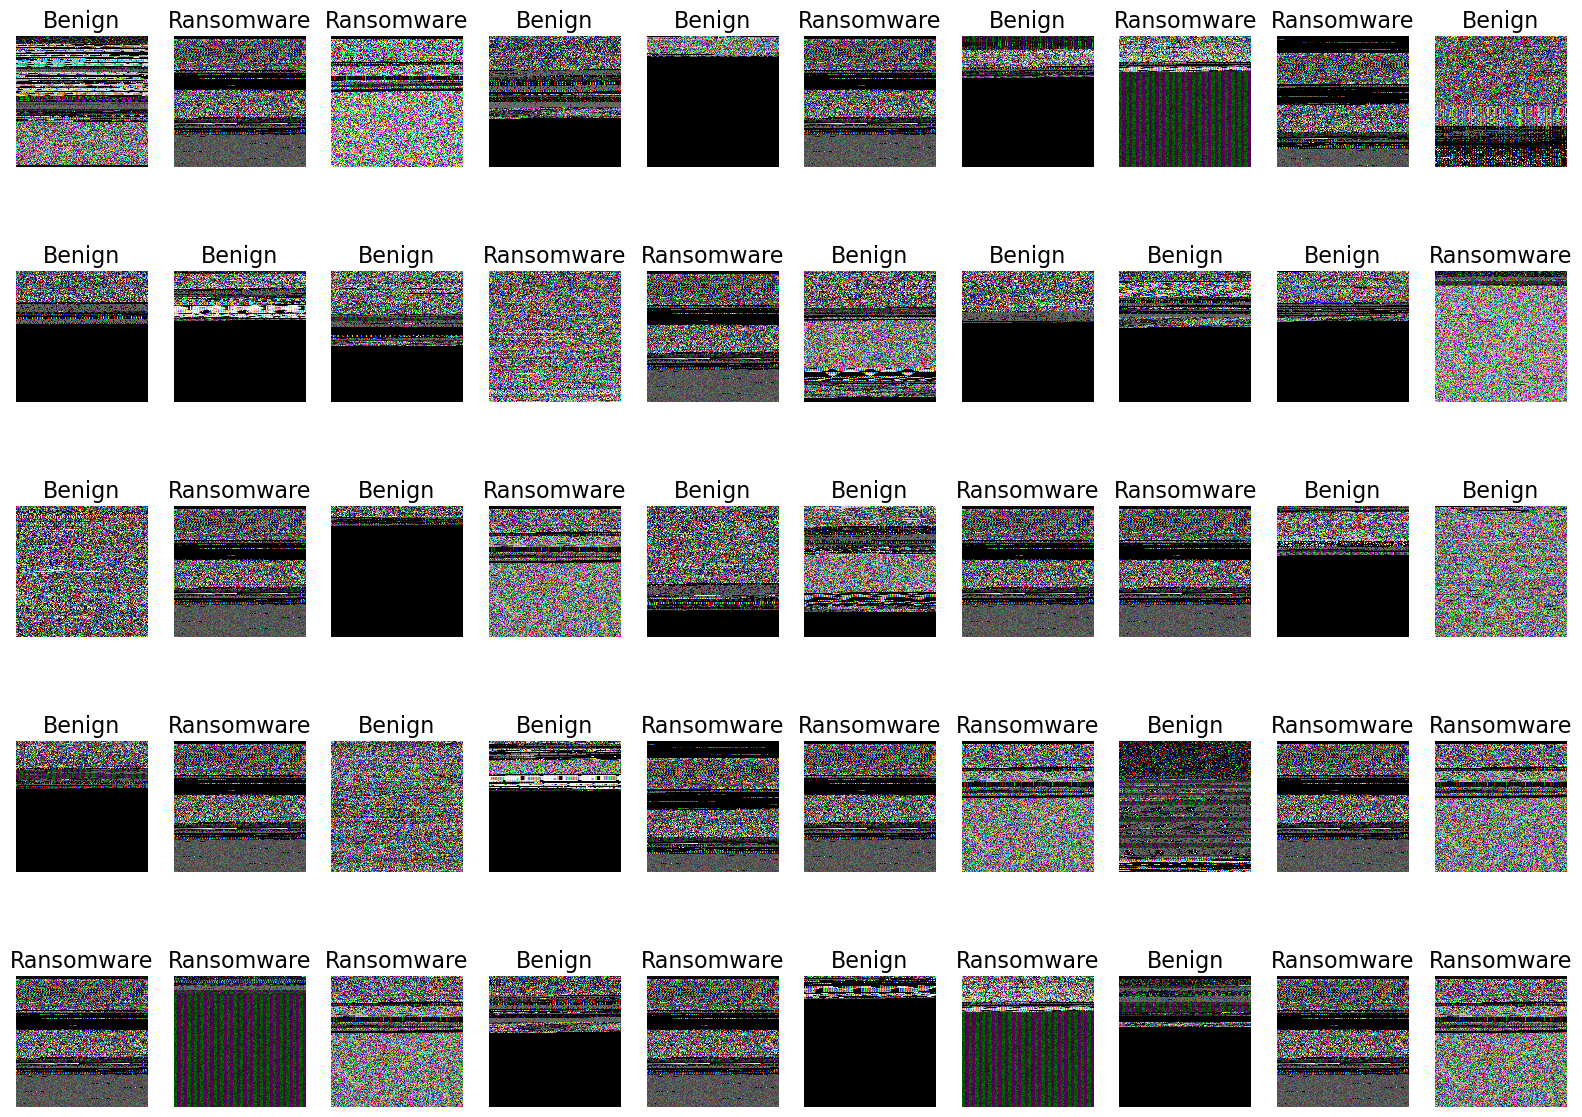

In [10]:
plots(imgs, titles = labels)

We can already observe differences between classes.

# Analyse 

All our images are finally ready to be used. Lets check out the repartition of data between classes :

In [11]:
classes = batches.class_indices.keys()

In [12]:
perc = (sum(labels)/labels.shape[0])*100

<BarContainer object of 2 artists>

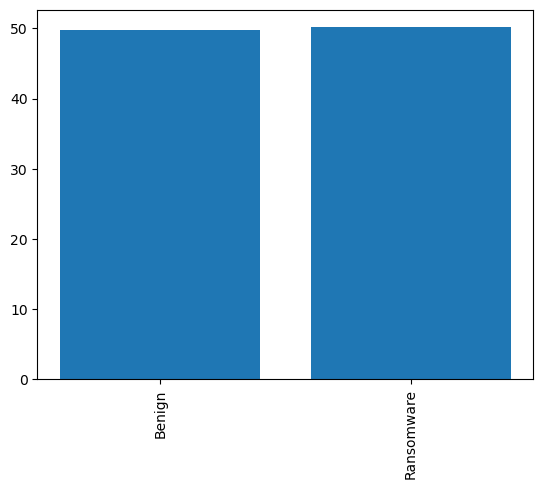

In [13]:
plt.xticks(rotation='vertical')
plt.bar(classes,perc)

# Train and test

Lets split our model into train and test following a ratio 70% train - 30% test ratio.

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(imgs/255.,labels, test_size=0.3)

In [15]:
X_train.shape

(212, 224, 224, 3)

In [16]:
X_test.shape

(91, 224, 224, 3)

In [17]:
y_train.shape

(212, 2)

In [18]:
y_test.shape

(91, 2)

## Convolutional Neural Network Model

*Our* **CNN** model using Keras. This model will have the following layers :

* **Convolutional Layer** : 30 filters, (3 * 3) kernel size
* **Max Pooling Layer** : (2 * 2) pool size
* **Convolutional Layer** : 15 filters, (3 * 3) kernel size
* **Max Pooling Layer** : (2 * 2) pool size
* **DropOut Layer** : Dropping 25% of neurons.
* **Flatten Layer**
* **Dense/Fully Connected Layer** : 128 Neurons, Relu activation function
* **DropOut Layer** : Dropping 50% of neurons.
* **Dense/Fully Connected Layer** : 50 Neurons, Softmax activation function
* **Dense/Fully Connected Layer** : num_class Neurons, Softmax activation function

**Input shape** : 64 * 64 * 3

In [19]:
import keras
import tensorflow
from keras.models import Sequential, Model
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, Input
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.metrics import AUC



In [20]:
num_classes = 2

Building the model

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras import regularizers



def malware_model():

    
    model = Sequential()

    model.add(Conv2D(30, kernel_size=(3, 3),
                    activation='relu',
                    input_shape=(224,224,3)))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(224, kernel_size=(3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(2, activation='softmax'))  # Change this line if you have 2 classes
 

    return model






In [22]:
from keras import backend as K

import tensorflow.keras.backend as K

def precision_m(y_test, y_pred):
    true_positives = K.sum(K.round(K.clip(y_test * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    return precision

def recall_m(y_test, y_pred):
    true_positives = K.sum(K.round(K.clip(y_test * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_test, 0, 1)))
    recall = true_positives / (possible_positives + K.epsilon())
    return recall


def f1_m(y_test, y_pred):
    precision = precision_m(y_test, y_pred)
    recall = recall_m(y_test, y_pred)
    return 2*((precision*recall)/(precision+recall+K.epsilon()))




In [23]:

Malware_model = malware_model()

c:\Users\aimaa\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


In [24]:
Malware_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 30)   │           840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 30)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        17,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 224)    │       258,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 224)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32256)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,128,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,479,466 (17.09 MB)

 Trainable params: 4,479,466 (17.09 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
y_train.shape

(212, 2)



**class_weights** uses the values of y to automatically adjust weights inversely proportional to class frequencies in the input data. To use this method, y_train must not be one hot encoded.

In [26]:
from sklearn.neighbors import KNeighborsClassifier
y_train_new = np.argmax(y_train, axis=1)
y_test_new = np.argmax(y_test, axis=1)
X_train_new = np.argmax(X_train, axis=1)

print("Original shape of X_train:", X_train.shape)
if X_train.ndim > 2:
    n_samples = X_train.shape[0]
    X_train_reshaped = X_train.reshape(n_samples, -1)
    print("Reshaped X_train to:", X_train_reshaped.shape)
else:
    X_train_reshaped = X_train
classifier = KNeighborsClassifier(n_neighbors=1, metric='minkowski', p=2)
classifier.fit(X_train_reshaped,y_train_new)


#y_train_new = np.argmax(y_train, axis=1)

Original shape of X_train: (212, 224, 224, 3)
Reshaped X_train to: (212, 150528)


KNeighborsClassifier(n_neighbors=1)

In [27]:
if X_test.ndim > 2:
    n_samples =  X_test.shape[0]
    X_test_reshaped = X_test.reshape(n_samples, -1)
    print("Reshaped X_train to:", X_test_reshaped.shape)
else:
    X_train_reshaped = X_train
y_pred=classifier.predict(X_test_reshaped)

Reshaped X_train to: (91, 150528)


In [28]:
y_test_new,y_pred


(array([0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1,
        0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
        0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
        1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1,
        0, 1, 1], dtype=int64),
 array([0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1,
        0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0,
        1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,
        1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
        0, 1, 1], dtype=int64))

In [29]:
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight(class_weight = 'balanced',
                                                 classes = np.unique(y_train_new),
                                                 y = y_train_new)
#class_weights = {i : class_weights[i] for i in range(5)}

class_weights = {l:c for l,c in zip(np.unique(y_train_new), class_weights)}



In [30]:
import tensorflow as tf

Malware_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[f1_m,precision_m, recall_m,AUC()])


In [31]:
from tensorflow.keras.callbacks import EarlyStopping

# Example: Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history= Malware_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=30, class_weight=class_weights)
# Now you can use Malware_model for training, validation, and testing

Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - auc: 0.6680 - f1_m: 0.6198 - loss: 0.7586 - precision_m: 0.6198 - recall_m: 0.6198 - val_auc: 0.9268 - val_f1_m: 0.8900 - val_loss: 0.5190 - val_precision_m: 0.8900 - val_recall_m: 0.8900
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - auc: 0.8369 - f1_m: 0.7450 - loss: 0.5145 - precision_m: 0.7450 - recall_m: 0.7450 - val_auc: 0.9713 - val_f1_m: 0.9317 - val_loss: 0.2598 - val_precision_m: 0.9317 - val_recall_m: 0.9317
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - auc: 0.9278 - f1_m: 0.8312 - loss: 0.3553 - precision_m: 0.8313 - recall_m: 0.8313 - val_auc: 0.9591 - val_f1_m: 0.8360 - val_loss: 0.2381 - val_precision_m: 0.8360 - val_recall_m: 0.8360
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - auc: 0.9708 - f1_m: 0.9209 - loss: 0.2230 - precision_m: 0.9209 - recall_m: 0.9209 - val_auc: 0.9883 - val_f1_m: 0.9213 - val_loss: 0.1692 - val_precision_m: 0.9213 - val_recall_m: 0.9213
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step 

In [32]:
scores = Malware_model.evaluate(X_test, y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 344ms/step - auc: 0.9884 - f1_m: 0.9847 - loss: 0.0795 - precision_m: 0.9847 - recall_m: 0.9847


In [33]:
scores2 = Malware_model.evaluate(X_train, y_train)

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 363ms/step - auc: 0.9953 - f1_m: 0.9602 - loss: 0.0909 - precision_m: 0.9602 - recall_m: 0.9602


In [34]:
loss, accuracy, f1_score, precision, recall = Malware_model.evaluate(X_test, y_test)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 352ms/step - auc: 0.9884 - f1_m: 0.9847 - loss: 0.0795 - precision_m: 0.9847 - recall_m: 0.9847


In [35]:
print('Final CNN accuracy:', round(scores[1] * 100, 2), "%")


Final CNN accuracy: 98.6 %


# Confusion Matrix

Lets analyse our results.

In [36]:
import numpy as np
import pandas as pd

In [37]:
y_pred = np.argmax(Malware_model.predict(X_test), axis=-1)



3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 374ms/step


In [38]:
y_pred

array([0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 1, 1], dtype=int64)

In [39]:
y_test2 = np.argmax(y_test, axis=1)

In [40]:
y_test2

array([0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1,
       0, 1, 1], dtype=int64)

In [41]:
from sklearn import metrics
c_matrix = metrics.confusion_matrix(y_test2, y_pred)

In [42]:
import seaborn as sns
def confusion_matrix(confusion_matrix, class_names, figsize = (10,7), fontsize=14):
    
    df_cm = pd.DataFrame(
        confusion_matrix, index=class_names, columns=class_names, 
    )
    fig = plt.figure(figsize=figsize)
    try:
        heatmap = sns.heatmap(df_cm, annot=True, fmt="d")
    except ValueError:
        raise ValueError("Confusion matrix values must be integers.")
    heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0, ha='right', fontsize=fontsize)
    heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=45, ha='right', fontsize=fontsize)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

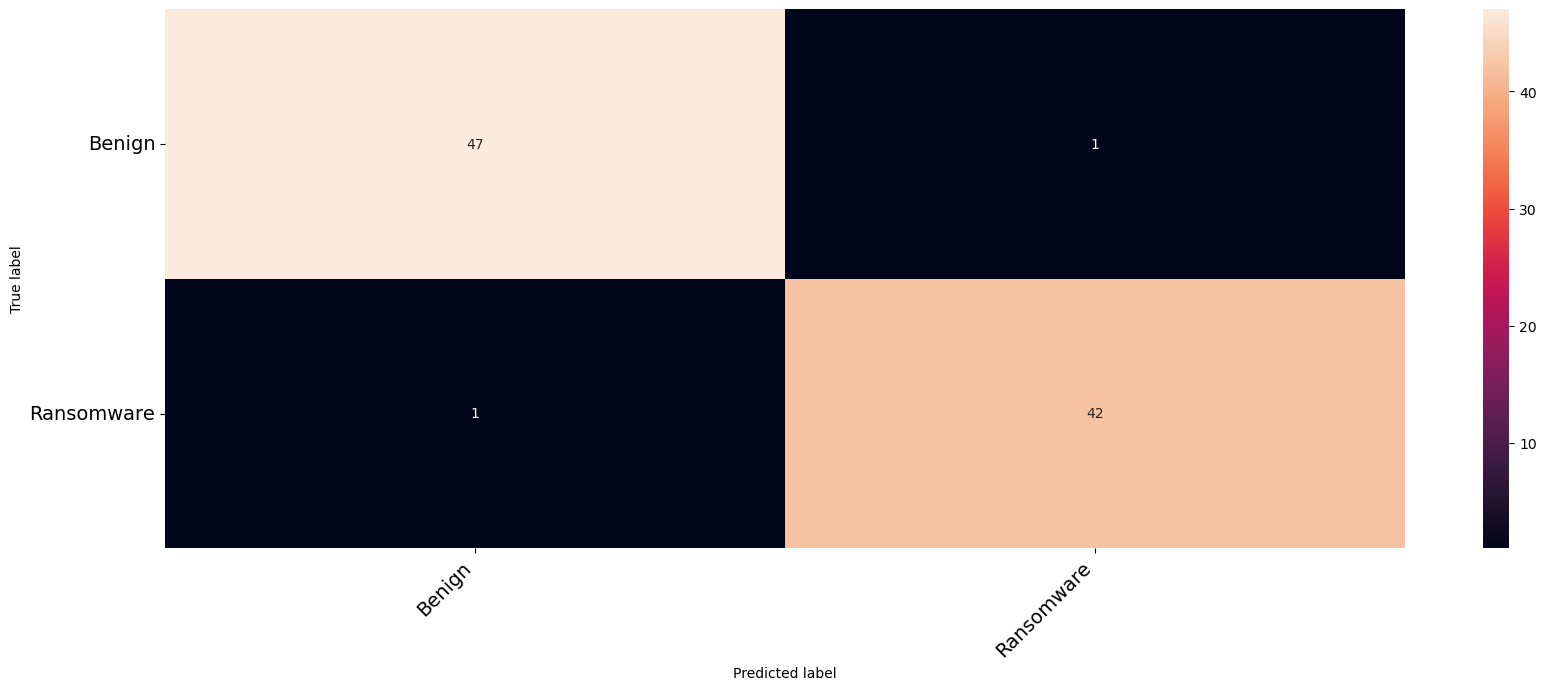

In [43]:
class_names= batches.class_indices.keys()
confusion_matrix(c_matrix, class_names, figsize = (20,7), fontsize=14)

In [44]:
import pandas as pd

# Assuming scores is a list containing evaluation metrics
results = pd.DataFrame({ 
    'CNN Model': 'Ransomware model',    
    'Accuracy': ['{:.2f}%'.format(scores[1] * 100)],  # Format as percentage with two decimal places
    'Loss': ['{:.2f}'.format(scores[0])],
    'Precision': ['{:.2f}%'.format(scores[3] * 100)],  # Format as percentage with two decimal places
    'Recall': ['{:.2f}%'.format(scores[4] * 100)],     # Format as percentage with two decimal places
    'F1 Score': ['{:.2f}%'.format(scores[2] * 100)]    # Format as percentage with two decimal places
})

print(results)


          CNN Model Accuracy  Loss Precision  Recall F1 Score
0  Ransomware model   98.60%  0.10    97.72%  97.72%   97.72%


In [45]:
results

,CNN Model,Accuracy,Loss,Precision,Recall,F1 Score
0,Ransomware model,98.60%,0.10,97.72%,97.72%,97.72%


In [46]:
from sklearn.metrics import classification_report
import numpy as np

Y_test = np.argmax(y_test, axis=1) # Convert one-hot to index
y_pred = np.argmax(Malware_model.predict(X_test), axis=-1)
print(classification_report(Y_test, y_pred))

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 329ms/step
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        48
           1       0.98      0.98      0.98        43

    accuracy                           0.98        91
   macro avg       0.98      0.98      0.98        91
weighted avg       0.98      0.98      0.98        91



In [47]:
import pickle
import matplotlib.pyplot as plt
from PIL import Image
import keras
from keras.preprocessing.image import load_img, img_to_array 
from keras.models import load_model
import PIL


In [48]:
from keras.models import load_model

#Malware_model.save(r'C:\Users\aimaa\Desktop\New folder\1\model.h5')   

model = load_model(r"C:\Users\aimaa\Desktop\New folder\FYP\weights.keras")

In [49]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

try:
    # Load the image
    img = load_img("C:\\Users\\aimaa\\Desktop\\Degree\\Sem 6\\FYP\\Dataset\\combine")

    # Resize the image
    img = img.resize((64, 64))

    # Convert the image to a numpy array
    img_array = img_to_array(img)

    # Reshape the image array to match the expected input shape of your model
    img_array = img_array.reshape(-1, 64, 64, 3)

    # Display the resized image
    plt.imshow(img)
    plt.show()

    # Print the shape of the image array
    print("Image shape:", img_array.shape)

    # Assuming you have a pre-trained model and categories list
    # Make predictions using your model
    CATEGORIES = ['Ransomware', 'Benign']
    prediction = model.predict(img_array)
    pred_name = CATEGORIES[np.argmax(prediction)]
    print("Predicted class:", pred_name)
    print("Prediction probabilities:", prediction)

except Exception as e:
    print("Error:", e)


Error: [Errno 2] No such file or directory: 'C:\\Users\\aimaa\\Desktop\\Degree\\Sem 6\\FYP\\Dataset\\combine'


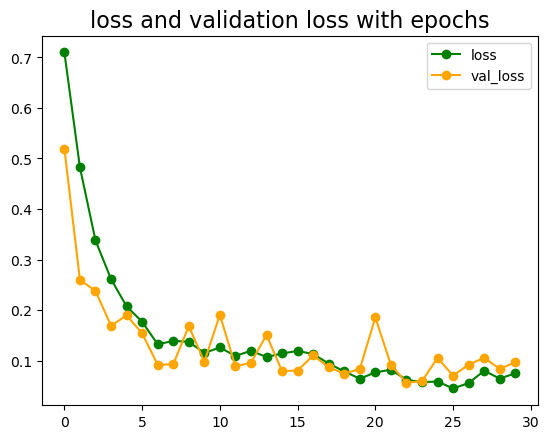

dict_keys(['auc', 'f1_m', 'loss', 'precision_m', 'recall_m', 'val_auc', 'val_f1_m', 'val_loss', 'val_precision_m', 'val_recall_m'])


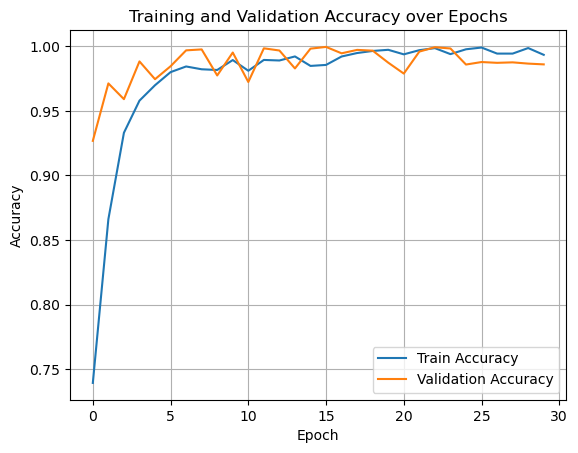

In [68]:

# plot loss function for train and validation.
plt.title('loss and validation loss with epochs', 
          fontsize=16)

plt.plot(history.history['loss'],
         marker='o',
         color="green",
         label="loss")

plt.plot(history.history['val_loss'],
         marker='o',
         color="orange", 
         label="val_loss")

plt.legend()
plt.show()

print(history.history.keys())



plt.plot(history.history['auc'], label='Train Accuracy')
plt.plot(history.history['val_auc'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
## Evaluate the model
#from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score
#
#y_pred = np.argmax(Malware_model.predict(X_test), axis=1)
#y_true = np.argmax(y_test, axis=1)
#
#precision = precision_score(y_true, y_pred)
#recall = recall_score(y_true, y_pred)
#f1 = f1_score(y_true, y_pred)
#
#print(f"Loss: {loss}")
#print(f"Accuracy: {accuracy}")
#print(f"Precision: {precision}")
#print(f"Recall: {recall}")
#print(f"F1 Score: {f1}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 322ms/step
True Positives: 42
False Positives: 1
True Negatives: 47
False Negatives: 1
Precision: 0.9767441860465116
Recall: 0.9767441860465116
F1 Score: 0.9767441860465116
True Positive Rate (TPR/Recall): 0.9767441860465116
False Positive Rate (FPR): 0.020833333333333332


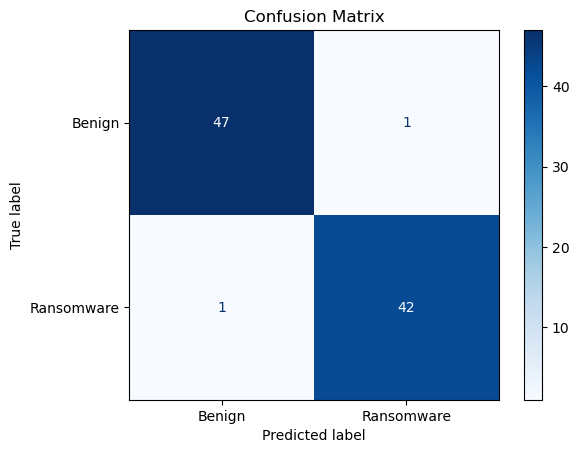

In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score

y_pred = np.argmax(Malware_model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)
cm = confusion_matrix(y_true, y_pred)
#c_matrix = metrics.confusion_matrix(y_test2, y_pred)

# Extract TP, FP, TN, FN
TN, FP, FN, TP = cm.ravel()

print(f"True Positives: {TP}")
print(f"False Positives: {FP}")
print(f"True Negatives: {TN}")
print(f"False Negatives: {FN}")

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

TPR = TP / (TP + FN)
FPR = FP / (FP + TN)

print(f"True Positive Rate (TPR/Recall): {TPR}")
print(f"False Positive Rate (FPR): {FPR}")

# Plot the confusion matrix
cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Ransomware'])
cmd.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 351ms/step - auc: 0.9953 - f1_m: 0.9602 - loss: 0.0909 - precision_m: 0.9602 - recall_m: 0.9602
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 363ms/step - auc: 0.9884 - f1_m: 0.9847 - loss: 0.0795 - precision_m: 0.9847 - recall_m: 0.9847


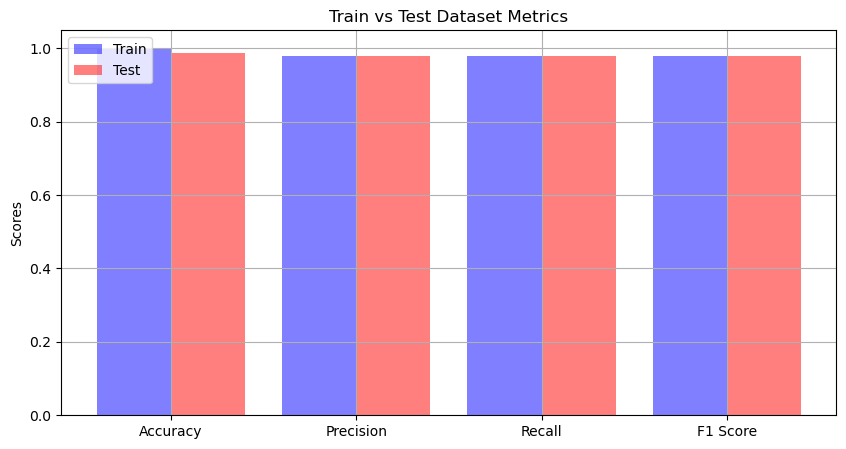

In [53]:
import matplotlib.pyplot as plt

loss, accuracy, f1_score, precision, recall = Malware_model.evaluate(X_train, y_train)
loss1, accuracy1, f1_score1, precision1, recall1 = Malware_model.evaluate(X_test, y_test)


# Sample data for the metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
train_scores = [accuracy, precision,recall,f1_score]
test_scores = [ accuracy1, precision1, recall1, f1_score1]

# Set the positions and width for the bars
pos = list(range(len(metrics))) 
width = 0.4

# Plotting the bars
fig, ax = plt.subplots(figsize=(10,5))

# Create bars for train scores
plt.bar(pos, train_scores, width, alpha=0.5, color='blue', label='Train')

# Create bars for test scores
plt.bar([p + width for p in pos], test_scores, width, alpha=0.5, color='red', label='Test')

# Set the y axis label
ax.set_ylabel('Scores')

# Set the chart's title
ax.set_title('Train vs Test Dataset Metrics')

# Set the position of the x ticks
ax.set_xticks([p + width/2 for p in pos])

# Set the labels for the x ticks
ax.set_xticklabels(metrics)

# Adding the legend and showing the plot
plt.legend(['Train', 'Test'], loc='upper left')
plt.grid()
plt.show()

In [69]:
epochs = 30
print("Length of train_acc:", len(train_acc))
print("Length of val_acc:", len(val_acc))
print("Epochs:", epochs)


Length of train_acc: 30
Length of val_acc: 30
Epochs: 30


In [70]:



import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import pandas as pd



# Extract training and validation accuracies
train_acc = history.history['auc']
val_acc = history.history['val_auc']

# Create a DataFrame to hold the results
results_df = pd.DataFrame({
    'Epoch': range(1, epochs + 1),
    'Train Accuracy': train_acc,
    'Validation Accuracy': val_acc
})

# Save the DataFrame to an Excel file
results_df.to_excel('training_results.xlsx', index=False)

print("Results saved to training_results.xlsx")


Results saved to training_results.xlsx
